In [1]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

In [2]:
### IOWA ###
# Load CSV
df = pd.read_csv("NRI_Table_CensusTracts.csv")

# Filter rows where STATEABBRV == "IA"
df_ia = df[df["STATEABBRV"] == "IA"]

# Overwrite the original DataFrame:
df = df[df["STATEABBRV"] == "IA"]
df_ia.to_csv("NRI_Table_CensusTracts_Iowa.csv", index=False)

df.head()

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
28970,29850,T19001960100,Iowa,IA,19,Adair,County,1,19001,960100,...,89.040693,Relatively High,0.000008,1.179377e-07,0.000001,93.185295,21440.003303,92.236376,Relatively High,December 2025
28971,29851,T19001960200,Iowa,IA,19,Adair,County,1,19001,960200,...,83.456895,Relatively High,0.000008,1.179377e-07,0.000001,94.915155,10272.152956,80.253107,Relatively High,December 2025
28972,29852,T19001960300,Iowa,IA,19,Adair,County,1,19001,960300,...,86.385888,Relatively High,0.000008,1.179377e-07,0.000001,89.976229,16452.407935,88.762706,Relatively High,December 2025
28973,29853,T19003950100,Iowa,IA,19,Adams,County,3,19003,950100,...,77.990774,Relatively Moderate,0.000009,6.660050e-08,0.000001,97.042764,9670.617208,79.007829,Relatively High,December 2025
28974,29854,T19003950200,Iowa,IA,19,Adams,County,3,19003,950200,...,81.803526,Relatively High,0.000009,6.660050e-08,0.000001,96.544988,11714.751491,82.865212,Relatively High,December 2025


In [3]:
### MISSOURI ###
# Load your CSV
df = pd.read_csv("NRI_Table_CensusTracts.csv")

# Filter rows where STATEABBRV == "MO"
df_mo = df[df["STATEABBRV"] == "MO"]

# If you just want to overwrite the original DataFrame:
df = df[df["STATEABBRV"] == "MO"]
df_mo.to_csv("NRI_Table_CensusTracts_Missouri.csv", index=False)

df.head()

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
42201,43081,T29001950100,Missouri,MO,29,Adair,County,1,29001,950100,...,56.626421,Relatively Moderate,0.000003,2.481977e-08,0.000001,87.939231,3789.239124,56.733439,Relatively Moderate,December 2025
42202,43082,T29001950200,Missouri,MO,29,Adair,County,1,29001,950200,...,50.726070,Relatively Moderate,0.000003,2.481977e-08,0.000001,88.129869,3371.759449,53.909220,Relatively Moderate,December 2025
42203,43083,T29001950300,Missouri,MO,29,Adair,County,1,29001,950300,...,56.228671,Relatively Moderate,0.000003,2.481977e-08,0.000001,89.902092,2405.148975,46.293361,Relatively Low,December 2025
42204,43084,T29001950400,Missouri,MO,29,Adair,County,1,29001,950400,...,58.029137,Relatively Moderate,0.000003,2.481977e-08,0.000001,87.327308,3509.903380,54.887567,Relatively Moderate,December 2025
42205,43085,T29001950501,Missouri,MO,29,Adair,County,1,29001,950501,...,59.422439,Relatively Moderate,0.000003,2.481977e-08,0.000001,88.602933,3228.602839,52.871289,Relatively Moderate,December 2025


In [4]:
## Load in CSV's
ia_nri = pd.read_csv("NRI_Table_CensusTracts_Iowa.csv")
ia_svi = pd.read_csv("Iowa.csv")
mo_nri = pd.read_csv("NRI_Table_CensusTracts_Missouri.csv")
mo_svi = pd.read_csv("Missouri.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")



In [5]:

## Student merge of NRI and SVI data
### Create a column in Census Tract called "STCNTY"
ia_nri['STCNTY'] = ia_nri['STCOFIPS']
mo_nri['STCNTY'] = mo_nri['STCOFIPS']

##Let's use merge to join our data
### Merge without repeat column names
ia = pd.merge(ia_nri, ia_svi, on = 'STCNTY', suffixes=('', '_right'))
mo = pd.merge(ia_nri, ia_svi, on = 'STCNTY', suffixes=('', '_right'))

In [8]:
#Replace values 
ia = ia.replace(-9999, np.nan)
mo = mo.replace(-9999, np.nan)

#Count missing values

ia_missing = ia.isna().sum()
ia_missing = ia_missing[ia_missing > 0].sort_values(ascending=False)

mo_missing = mo.isna().sum()
mo_missing = mo_missing[mo_missing > 0].sort_values(ascending=False)

#Drop columns that ALL values are NA
ia = ia.dropna(axis=1, how='all')
mo = mo.dropna(axis=1, how='all')

In [21]:
#Custom Risk Columns for Iowa
ia['tornado_risk'] = ia['TRND_AFREQ'] * ia['TRND_EXPT']
ia['winterweather_risk'] = ia['WNTW_AFREQ'] * ia['WNTW_EXPT']

#Custom Risk Columns for Missouri
mo['tornado_risk'] = mo['TRND_AFREQ'] * mo['TRND_EXPT']
mo['winterweather_risk'] = mo['WNTW_AFREQ'] * mo['WNTW_EXPT']

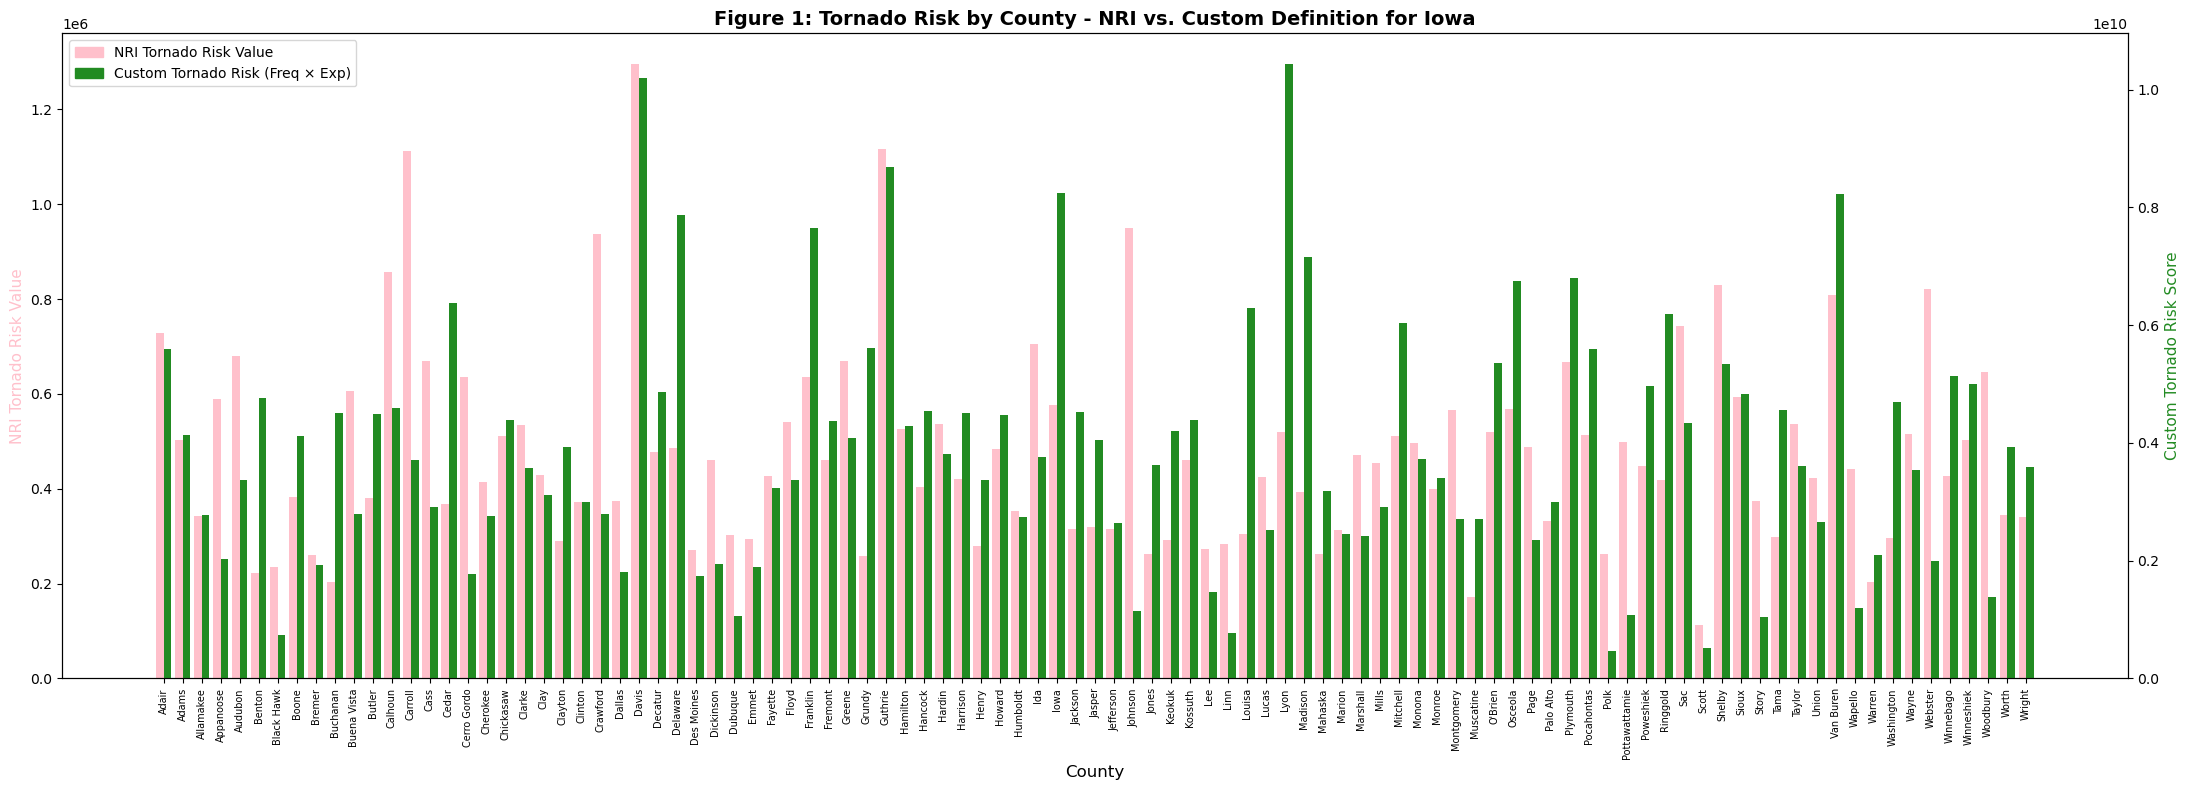

In [39]:
#Group Iowa data by county
ia_grouped = ia.groupby('COUNTY').agg(
    nri_tornado=('TRND_RISKV', 'mean'),
    my_tornado=('tornado_risk', 'mean'),
    nri_winter=('WNTW_RISKV', 'mean'),
    my_winter=('winterweather_risk', 'mean')
).reset_index()

#Figure 1
fig, ax1 = plt.subplots(figsize=(22, 8))
ax2 = ax1.twinx()

x = np.arange(len(ia_grouped))
ax1.bar(x - 0.2, ia_grouped['nri_tornado'], 0.4, color='pink', label='NRI Tornado Risk Value')
ax2.bar(x + 0.2, ia_grouped['my_tornado'], 0.4, color='forestgreen', label='Custom Tornado Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(ia_grouped['COUNTY'], rotation=90, fontsize=7)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Tornado Risk Value', color='pink', fontsize=11)
ax2.set_ylabel('Custom Tornado Risk Score', color='forestgreen', fontsize=11)
ax1.tick_params(axis='x', rotation=90)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['pink','forestgreen']]
ax1.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper left')

plt.title('Figure 1: Tornado Risk by County - NRI vs. Custom Definition for Iowa',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 1: Tornado Risk by County - NRI vs. Custom Definition for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

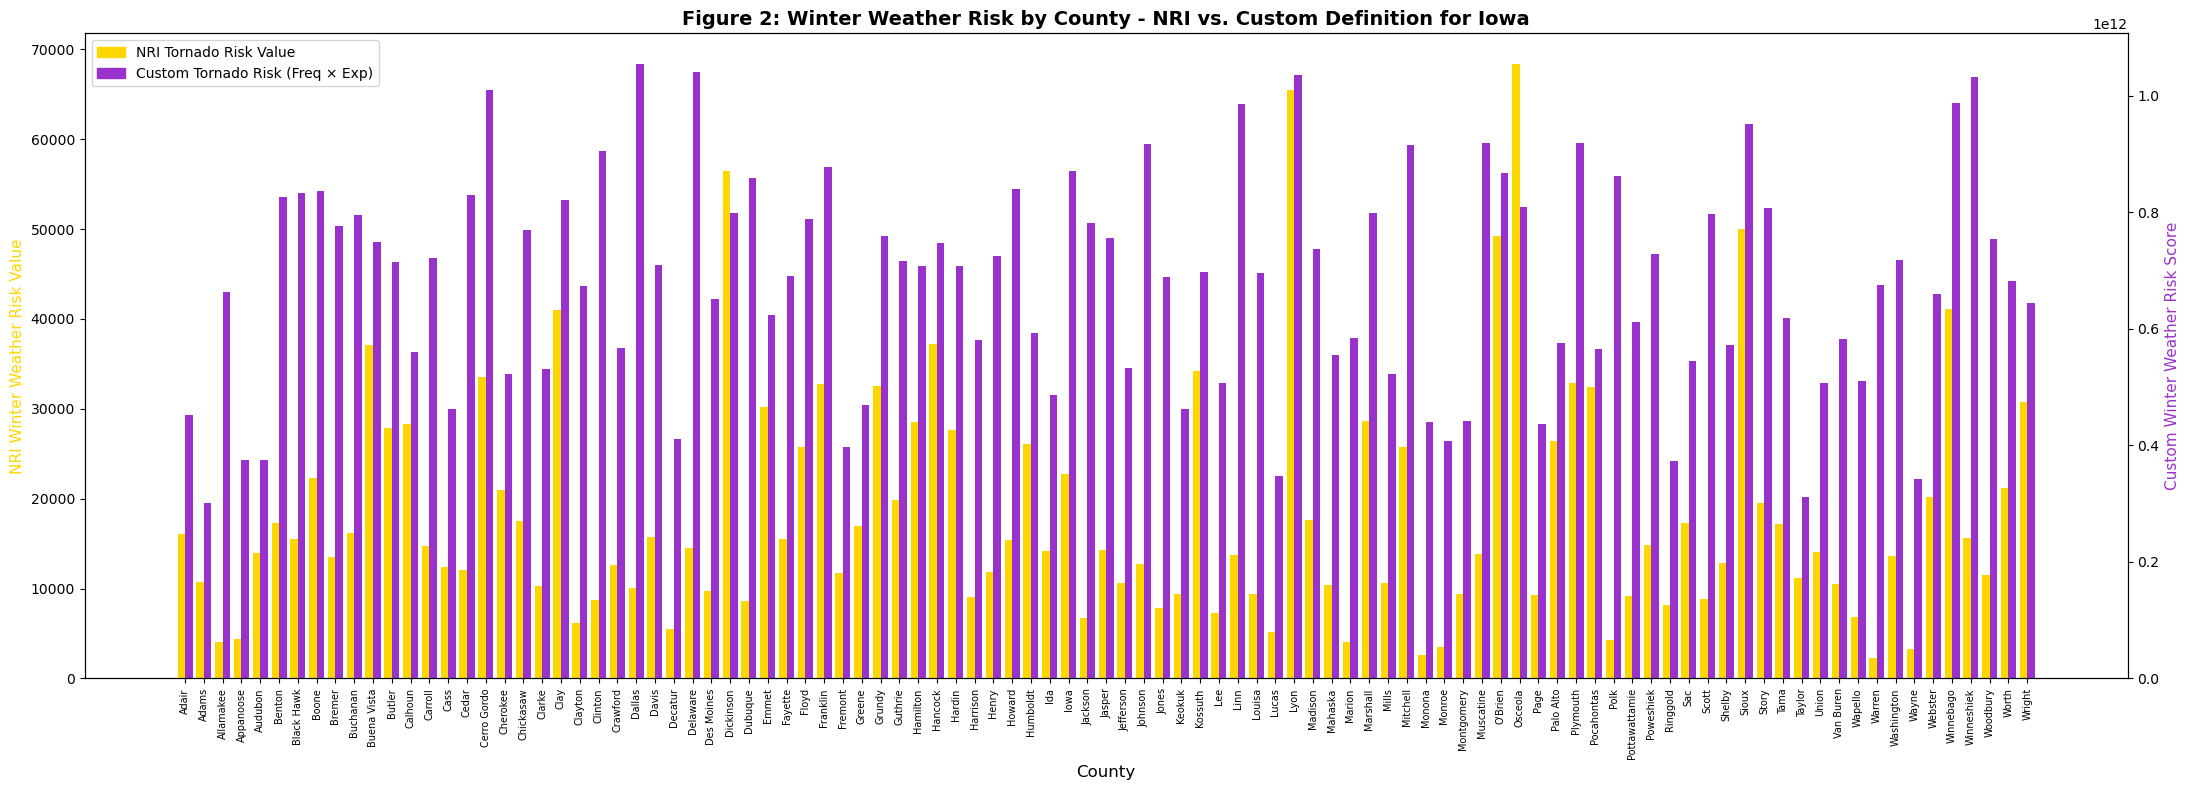

In [42]:
fig, ax1 = plt.subplots(figsize=(22, 8))
ax2 = ax1.twinx()

x = np.arange(len(ia_grouped))
ax1.bar(x - 0.2, ia_grouped['nri_winter'], 0.4, color='gold', label='NRI Winter Weather Risk Value')
ax2.bar(x + 0.2, ia_grouped['my_winter'], 0.4, color='darkorchid', label='Custom Winter Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(ia_grouped['COUNTY'], rotation=90, fontsize=7)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Winter Weather Risk Value', color='gold', fontsize=11)
ax2.set_ylabel('Custom Winter Weather Risk Score', color='darkorchid', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['gold','darkorchid']]
ax1.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper left')

plt.title('Figure 2: Winter Weather Risk by County - NRI vs. Custom Definition for Iowa',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 2: Winter Weather Risk by County - NRI vs. Custom Definition for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

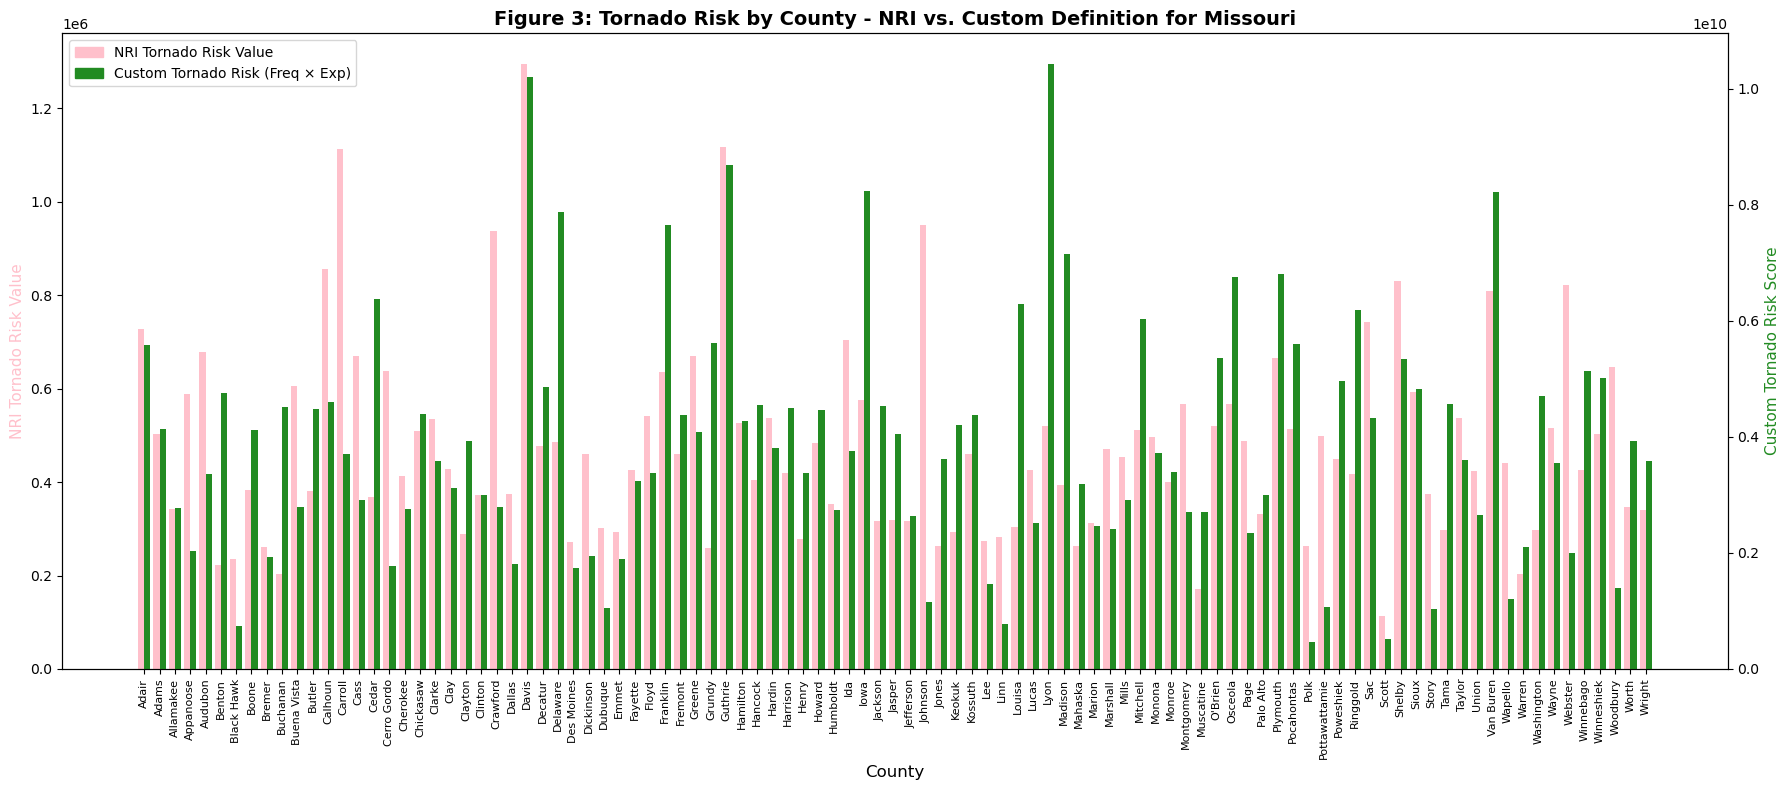

In [33]:
#Group Missouri data by county
mo_grouped = mo.groupby('COUNTY').agg(
    nri_tornado=('TRND_RISKV', 'mean'),
    my_tornado=('tornado_risk', 'mean'),
    nri_winter=('WNTW_RISKV', 'mean'),
    my_winter=('winterweather_risk', 'mean')
).reset_index()

#Figure 3: Tornado Risk Comparison
fig, ax1 = plt.subplots(figsize=(18, 8))
ax2 = ax1.twinx()

x = np.arange(len(mo_grouped))
ax1.bar(x - 0.2, mo_grouped['nri_tornado'], 0.4, color='steelblue', label='NRI Tornado Risk Value')
ax2.bar(x + 0.2, mo_grouped['my_tornado'], 0.4, color='forestgreen', label='Custom Tornado Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(mo_grouped['COUNTY'], rotation=90, fontsize=8)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Tornado Risk Value', color='pink', fontsize=11)
ax2.set_ylabel('Custom Tornado Risk Score', color='forestgreen', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['pink','forestgreen']]
ax1.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper left')

plt.title('Figure 3: Tornado Risk by County - NRI vs. Custom Definition for Missouri',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 3: Tornado Risk by County - NRI vs. Custom Definition for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()

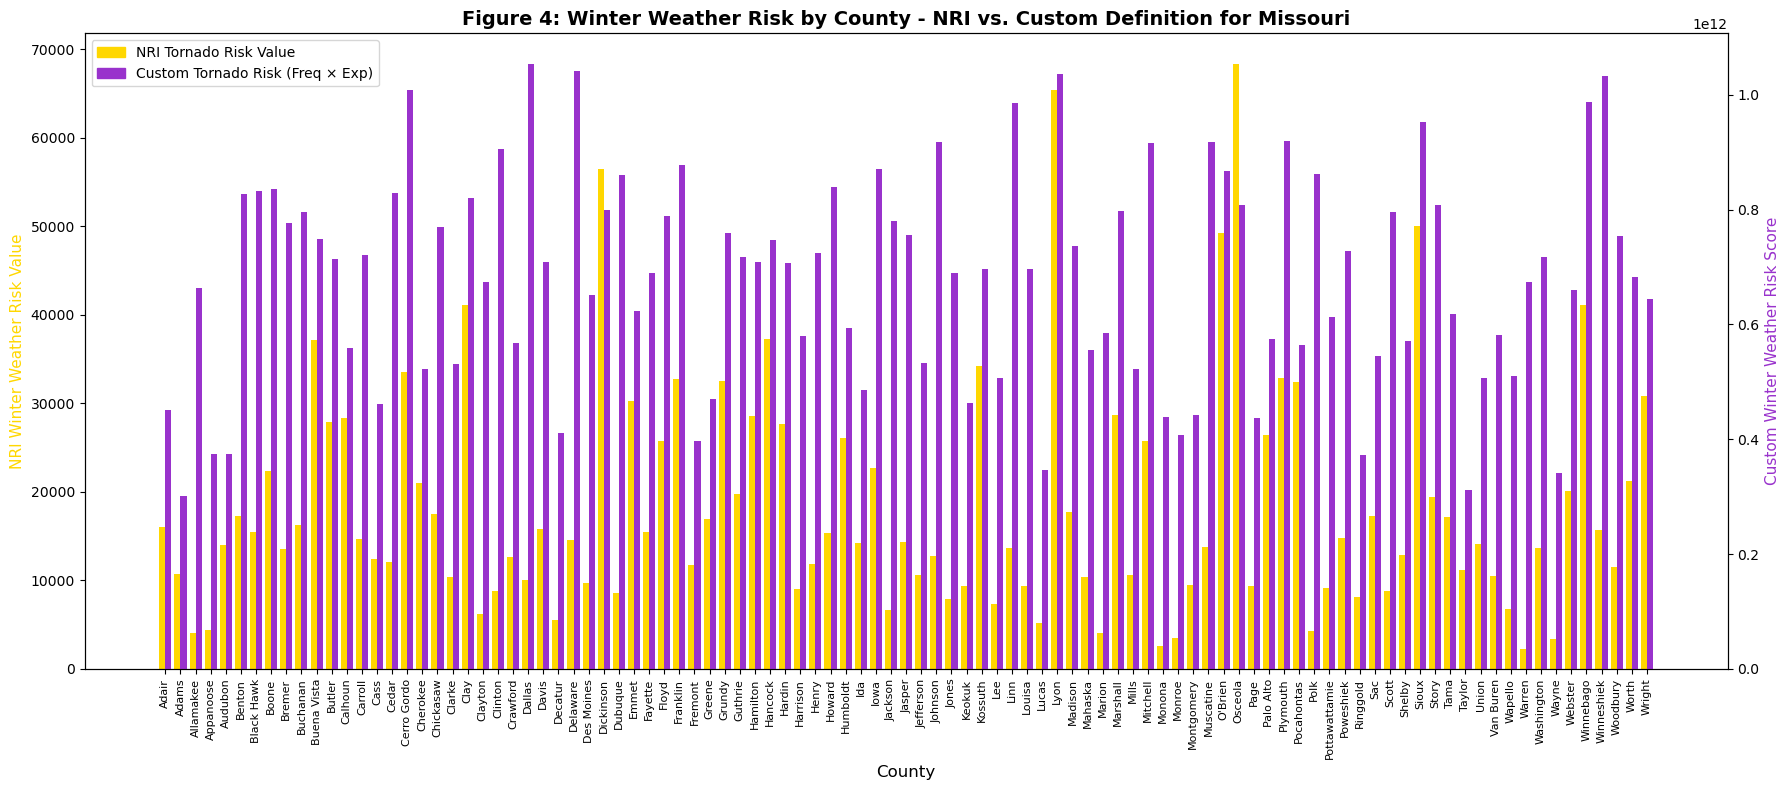

In [41]:
#Figure 4: Winter Weather Risk 
fig, ax1 = plt.subplots(figsize=(18, 8))
ax2 = ax1.twinx()

x = np.arange(len(mo_grouped))
ax1.bar(x - 0.2, mo_grouped['nri_winter'], 0.4, color='gold', label='NRI Winter Weather Risk Value')
ax2.bar(x + 0.2, mo_grouped['my_winter'], 0.4, color='darkorchid', label='Custom Winter Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(mo_grouped['COUNTY'], rotation=90, fontsize=8)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Winter Weather Risk Value', color='gold', fontsize=11)
ax2.set_ylabel('Custom Winter Weather Risk Score', color='darkorchid', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['gold','darkorchid']]
ax1.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper left')


plt.title('Figure 4: Winter Weather Risk by County - NRI vs. Custom Definition for Missouri',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 4: Winter Weather Risk by County - NRI vs. Custom Definition for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [15]:
#Load the NRI Shapefile
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

#Set CRS
tracts_clean = tracts.set_crs(epsg=4326, inplace=True, allow_override=True)
tracts_clean = tracts_clean.to_crs(epsg=4326)

#Replace placeholders
tracts_clean = tracts_clean.replace(-9999, np.nan)

#Convert Projection
tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)

print("Shapefile loaded and projected successfully.")
print("CRS:", tracts_clean.crs)
print("Shape:", tracts_clean.shape)

#Add custom risk columns to the shapefile GeoDataFrame
tracts_clean['tornado_risk'] = tracts_clean['TRND_AFREQ'] * tracts_clean['TRND_EXPT']
tracts_clean['winter_weather_risk'] = tracts_clean['WNTW_AFREQ'] * tracts_clean['WNTW_EXPT']

print("Custom risk columns added to shapefile.")

Shapefile loaded and projected successfully.
CRS: EPSG:4326
Shape: (85154, 469)
Custom risk columns added to shapefile.


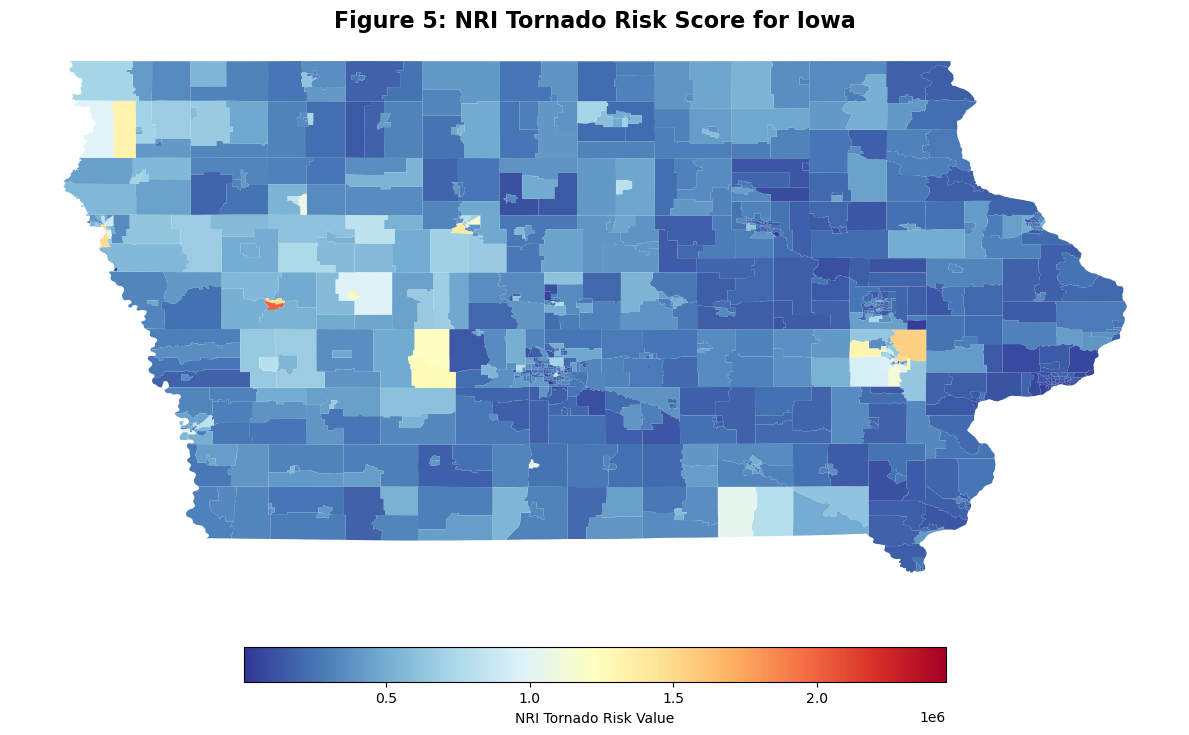

In [16]:
#Iowa NRI Tornado Risk
state_name = "Iowa"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="TRND_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Tornado Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 5: NRI Tornado Risk Score for Iowa", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 5: NRI Tornado Risk Score for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

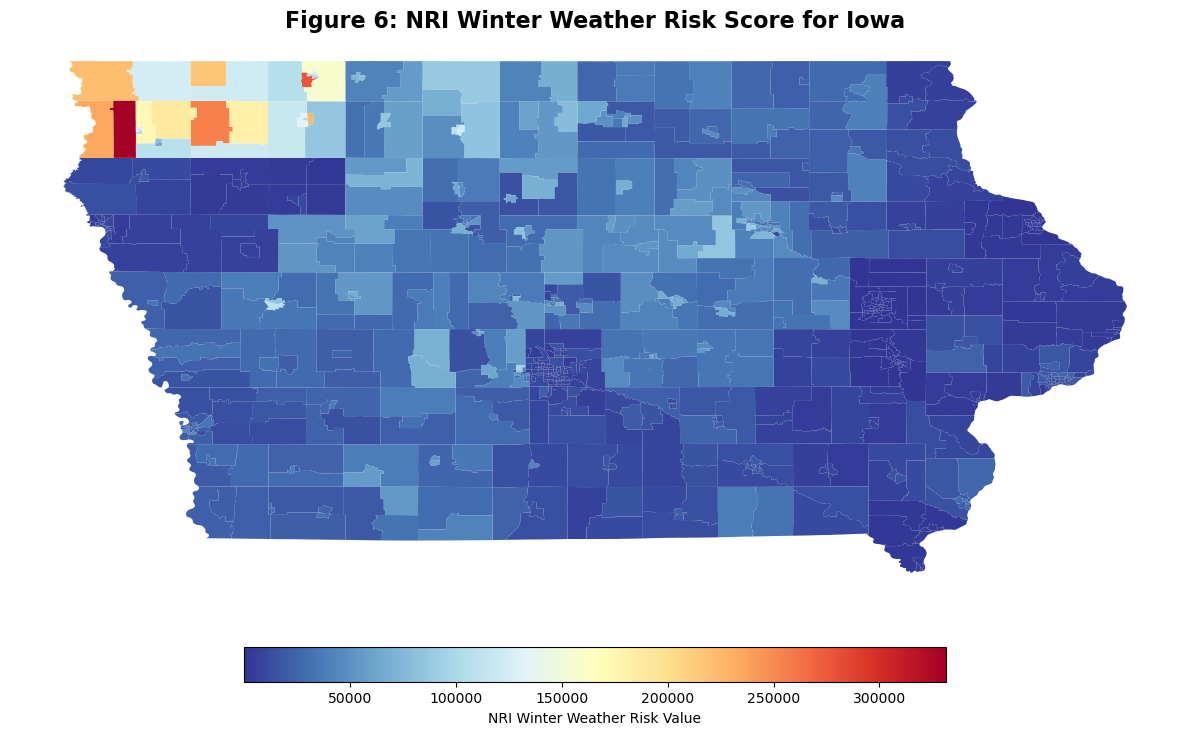

In [17]:
#Iowa NRI Winter Weather Risk
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="WNTW_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Winter Weather Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 6: NRI Winter Weather Risk Score for Iowa", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 6: NRI Winter Weather Risk Score for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

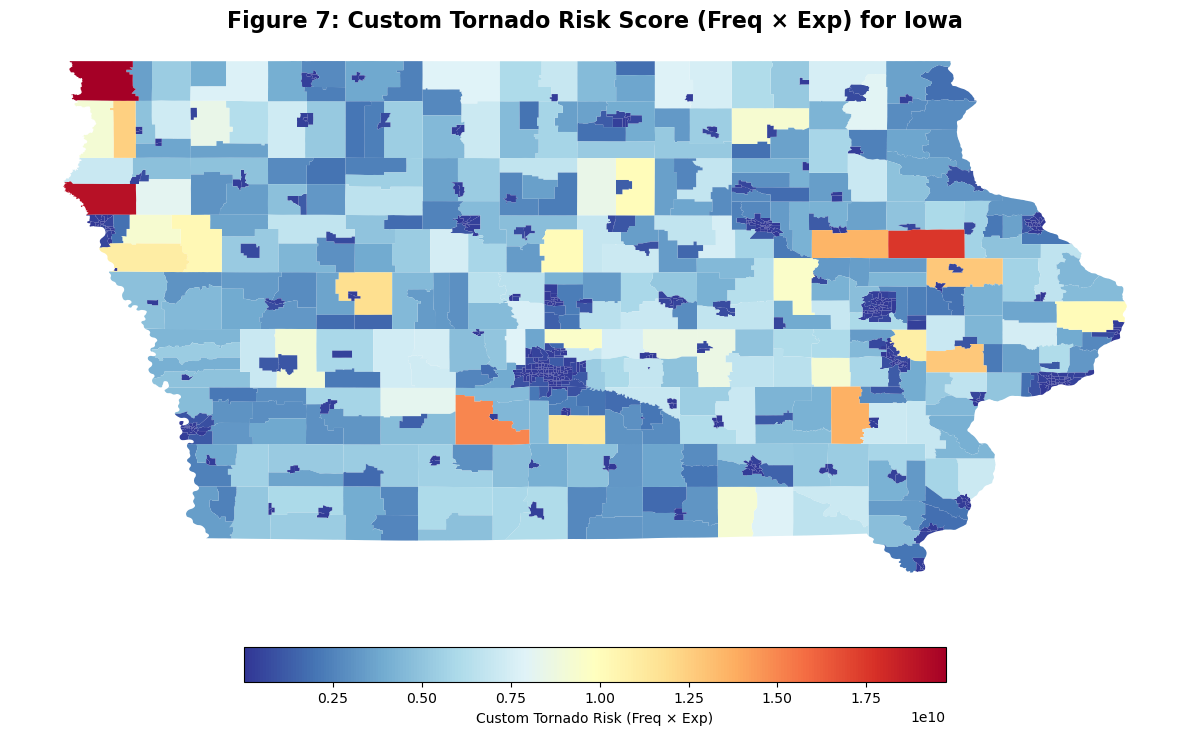

In [18]:
#Iowa Custom Tornado Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="tornado_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Tornado Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 7: Custom Tornado Risk Score (Freq × Exp) for Iowa", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 7: Custom Tornado Risk Score (Freq × Exp) for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

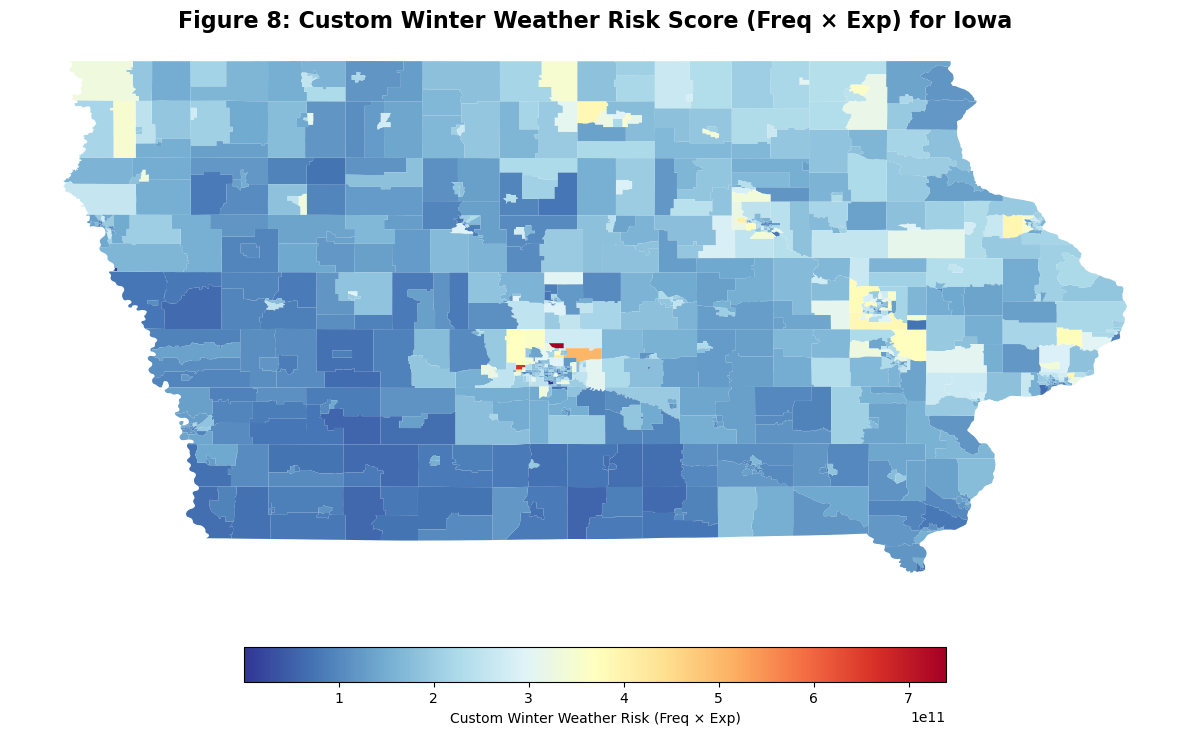

In [23]:
#Iowa Custom Winter Weather Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="winterweather_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Winter Weather Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 8: Custom Winter Weather Risk Score (Freq × Exp) for Iowa", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 8: Custom Winter Weather Risk Score (Freq × Exp) for Iowa.png", dpi = 300, bbox_inches = "tight")
plt.show()

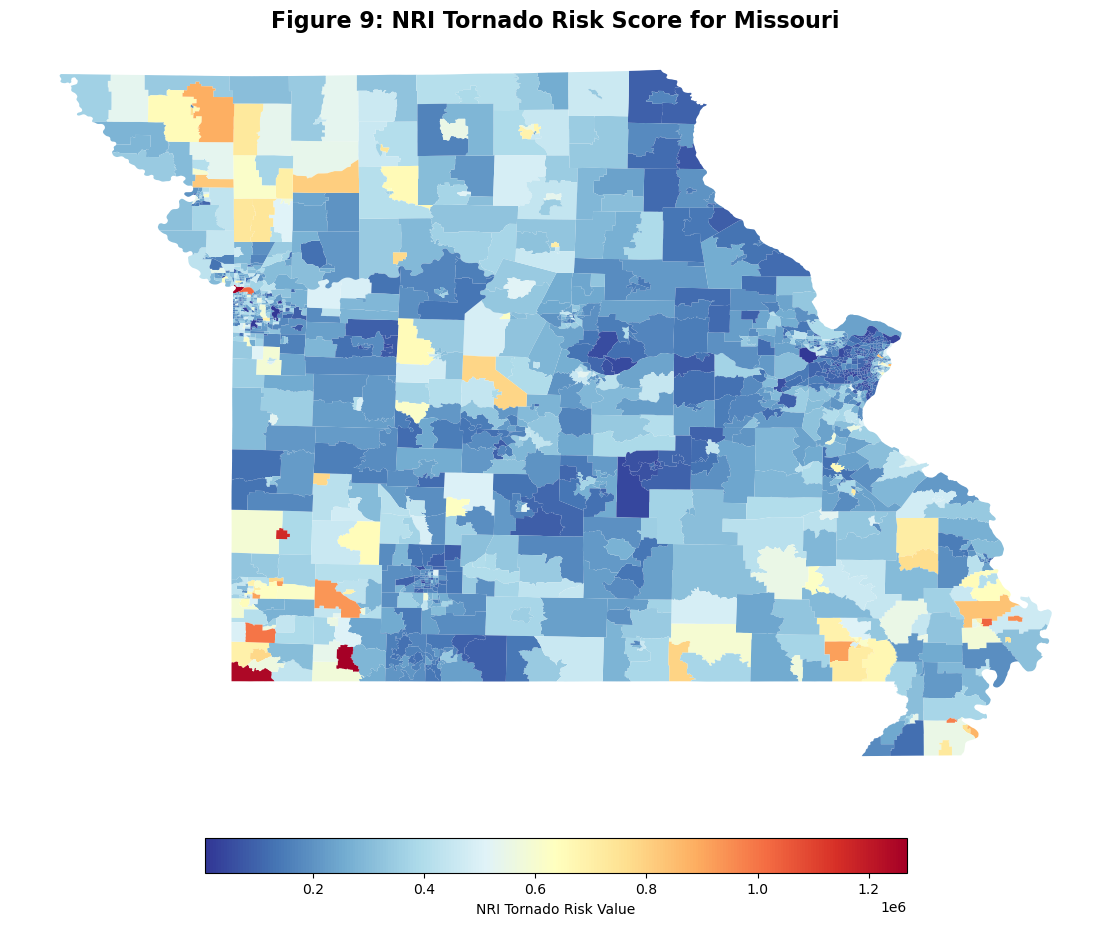

In [24]:
#Missouri NRI Tornado Risk
state_name = "Missouri"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="TRND_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Tornado Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 9: NRI Tornado Risk Score for Missouri", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 9: NRI Tornado Risk Score for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()

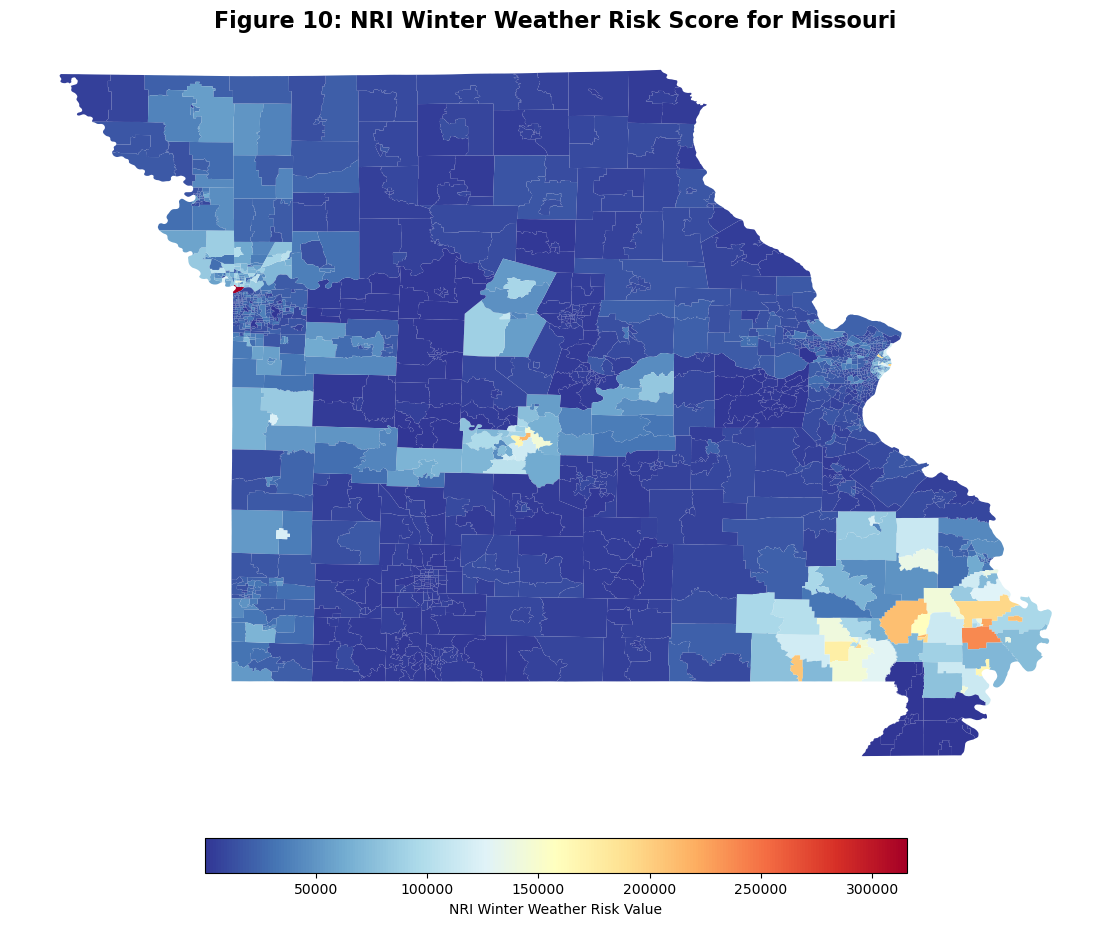

In [25]:
#Missouri NRI Winter Weather Risk
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="WNTW_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Winter Weather Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 10: NRI Winter Weather Risk Score for Missouri", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 10: NRI Winter Weather Risk Score for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()

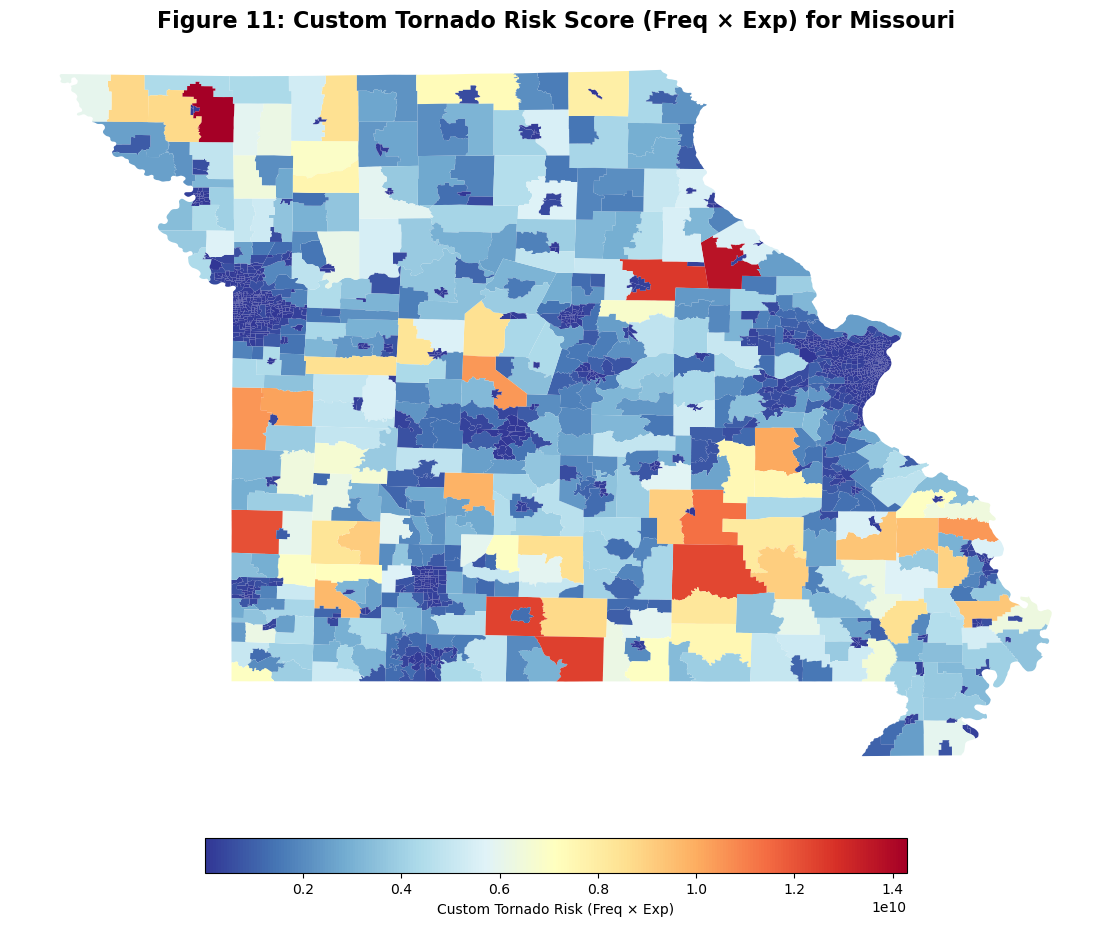

In [26]:
#Missouri Custom Tornado Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="tornado_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Tornado Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 11: Custom Tornado Risk Score (Freq × Exp) for Missouri", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 11: Custom Tornado Risk Score (Freq × Exp) for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()

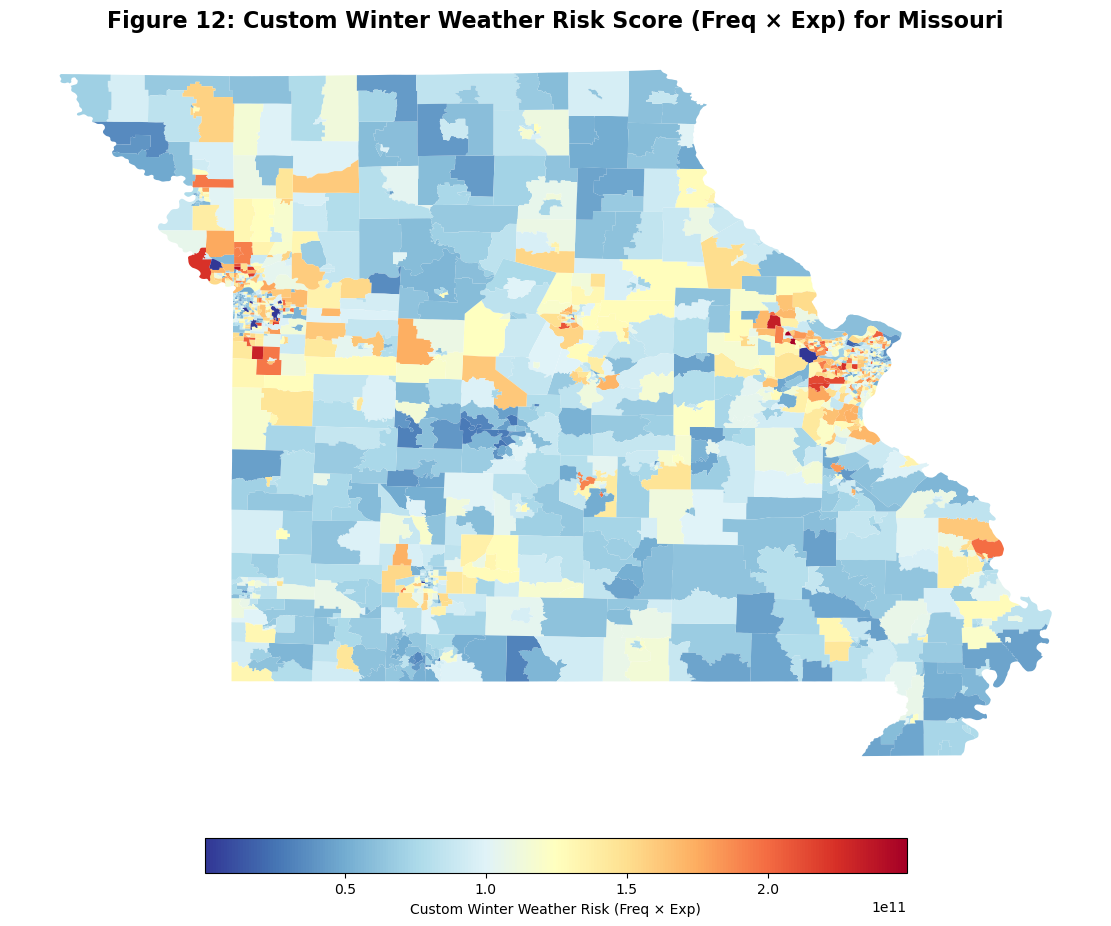

In [28]:
#Missouri Custom Winter Weather Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="winterweather_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Winter Weather Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Figure 12: Custom Winter Weather Risk Score (Freq × Exp) for Missouri", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Figure 12: Custom Winter Weather Risk Score (Freq × Exp) for Missouri.png", dpi = 300, bbox_inches = "tight")
plt.show()